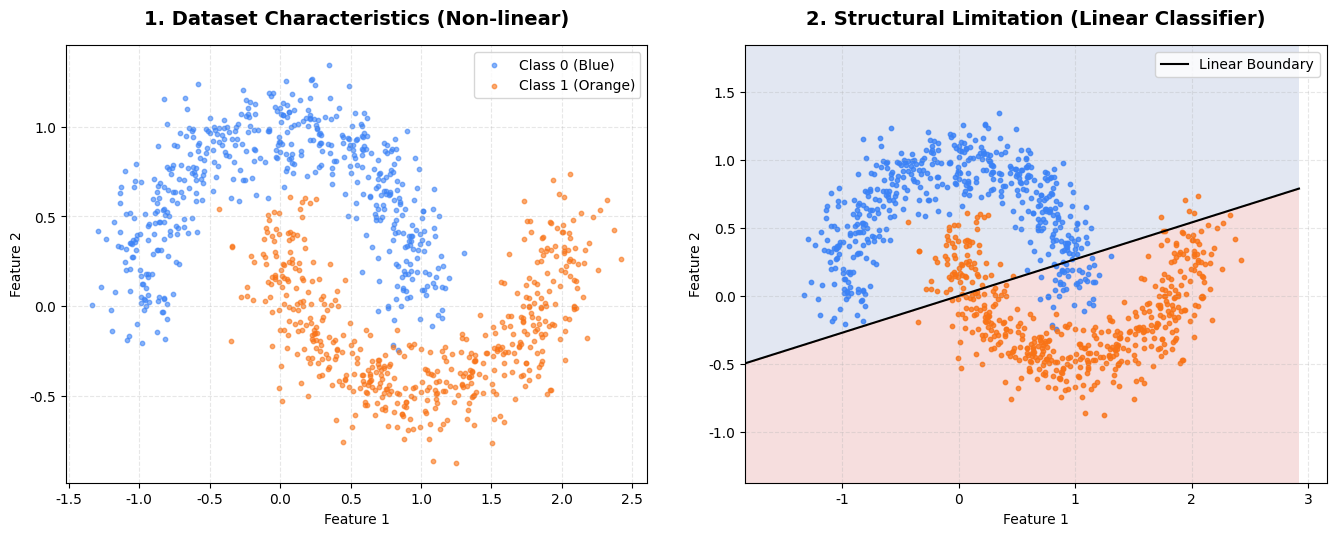

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.linear_model import Perceptron

# 한글 폰트 에러 방지용 (이전 설정 유지)
plt.rcParams['axes.unicode_minus'] = False

def plot_make_moons_analysis():
    # 1. make_moons 데이터셋 생성 (노이즈를 약간 섞어 현실감 부여)
    X, y = make_moons(n_samples=1000, noise=0.15, random_state=42)

    # 2. 퍼셉트론 모델 학습 (단일 선형 경계면 생성용)
    clf = Perceptron(random_state=42)
    clf.fit(X, y)

    # 3. 그래프 레이아웃 설정 (1행 2열)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # 데이터 클래스 분리
    X_class0 = X[y == 0]
    X_class1 = X[y == 1]

    # --------------------------------------------------
    # 첫 번째 그래프: 원본 make_moons 데이터셋
    # --------------------------------------------------
    ax1.scatter(X_class0[:, 0], X_class0[:, 1], color='#3b82f6', s=10, alpha=0.6, label='Class 0 (Blue)')
    ax1.scatter(X_class1[:, 0], X_class1[:, 1], color='#f97316', s=10, alpha=0.6, label='Class 1 (Orange)')

    ax1.set_title("1. Dataset Characteristics (Non-linear)", fontsize=14, fontweight='bold', pad=15)
    ax1.set_xlabel("Feature 1")
    ax1.set_ylabel("Feature 2")
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle='--', alpha=0.3)

    # --------------------------------------------------
    # 두 번째 그래프: 선형 분류기의 한계 (Decision Boundary)
    # --------------------------------------------------
    # 배경 색상을 칠하기 위한 메쉬그리드(Meshgrid) 생성
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    # 그리드 포인트들에 대한 예측값 계산 (배경색용)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # 배경색 칠하기 (등고선 형태)
    ax2.contourf(xx, yy, Z, alpha=0.15, cmap=plt.cm.RdYlBu_r)

    # 결정 경계선(직선) 그리기
    w = clf.coef_[0]
    b = clf.intercept_[0]
    # 방정식: w0*x + w1*y + b = 0  =>  y = -(w0/w1)*x - (b/w1)
    x_line = np.linspace(x_min, x_max, 100)
    y_line = -(w[0] / w[1]) * x_line - (b / w[1])
    ax2.plot(x_line, y_line, color='black', linewidth=1.5, linestyle='-', label='Linear Boundary')

    # 데이터 포인트 덧그리기
    ax2.scatter(X_class0[:, 0], X_class0[:, 1], color='#3b82f6', s=10, alpha=0.8)
    ax2.scatter(X_class1[:, 0], X_class1[:, 1], color='#f97316', s=10, alpha=0.8)

    ax2.set_title("2. Structural Limitation (Linear Classifier)", fontsize=14, fontweight='bold', pad=15)
    ax2.set_xlabel("Feature 1")
    ax2.set_ylabel("Feature 2")
    ax2.set_ylim(y_min, y_max) # y축 범위 고정
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle='--', alpha=0.3)

    # 레이아웃 조정 및 출력
    plt.tight_layout(pad=3.0)
    plt.show()

if __name__ == "__main__":
    plot_make_moons_analysis()

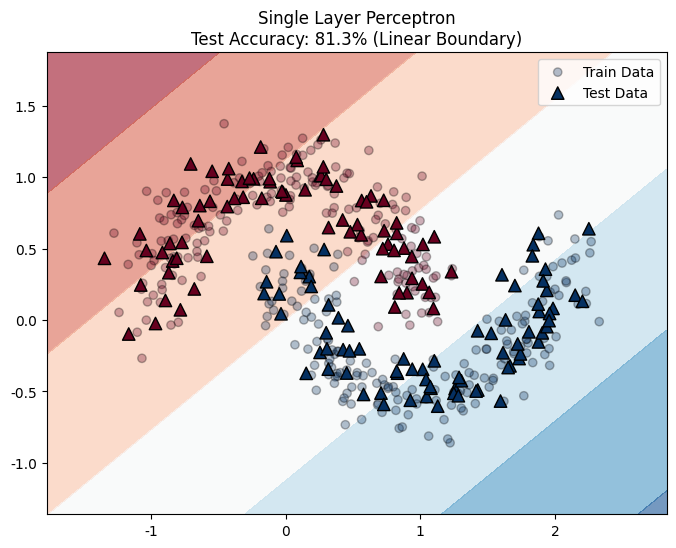

In [2]:
# Cell 1: 라이브러리 로드 및 데이터 분할
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.linear_model import Perceptron
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split

# 노이즈가 섞인 비선형 반달 모양 데이터셋 생성
X, y = make_moons(n_samples=500, noise=0.15, random_state=42)

# Train / Test 세트 분할 (7:3 비율)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 단층 퍼셉트론 모델 학습 (Train 데이터 기준)
perceptron_clf = Perceptron(random_state=42)
perceptron_clf.fit(X_train, y_train)

# 평가 (Test 데이터 기준 정확도 산출)
test_accuracy = perceptron_clf.score(X_test, y_test)

# 시각화 (결정 경계면 확인)
fig, ax = plt.subplots(figsize=(8, 6))
DecisionBoundaryDisplay.from_estimator(
    perceptron_clf, X_train, cmap=plt.cm.RdBu, alpha=0.6, ax=ax, eps=0.5
)

# Train 데이터는 반투명한 원형으로, Test 데이터는 진한 삼각형으로 구분하여 표시
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.RdBu, edgecolors='k', alpha=0.3, label='Train Data')
ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.RdBu, edgecolors='k', marker='^', s=80, label='Test Data')

ax.set_title(f"Single Layer Perceptron\nTest Accuracy: {test_accuracy*100:.1f}% (Linear Boundary)")
ax.legend()
plt.show()

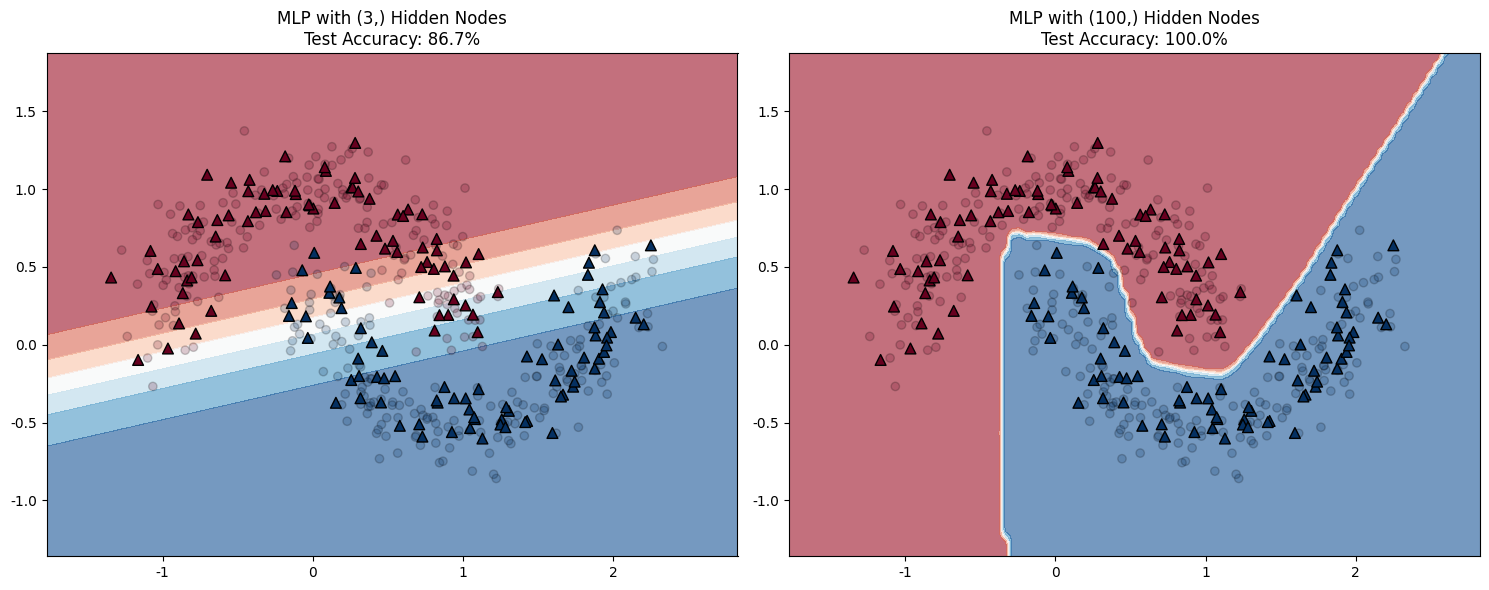

In [3]:
# Cell 2: 다층 퍼셉트론(MLP)의 은닉 노드 수에 따른 Test 정확도 및 결정 경계 비교
from sklearn.neural_network import MLPClassifier

# 비교할 은닉 노드 설정: 3개 vs 100개
hidden_nodes_list = [(3,), (100,)]
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, nodes in zip(axes, hidden_nodes_list):
    # MLP 모델 학습 (Train 데이터 기준)
    mlp = MLPClassifier(hidden_layer_sizes=nodes, activation='relu',
                        solver='lbfgs', random_state=42, max_iter=2000)
    mlp.fit(X_train, y_train)

    # 평가 (Test 데이터 기준 정확도 산출)
    test_acc = mlp.score(X_test, y_test)

    # 결정 경계면 시각화
    DecisionBoundaryDisplay.from_estimator(
        mlp, X_train, cmap=plt.cm.RdBu, alpha=0.6, ax=ax, eps=0.5
    )

    # 데이터 포인트 시각화 (Train: 투명, Test: 진하게)
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.RdBu, edgecolors='k', alpha=0.2)
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.RdBu, edgecolors='k', marker='^', s=60)

    ax.set_title(f"MLP with {nodes} Hidden Nodes\nTest Accuracy: {test_acc*100:.1f}%")

plt.tight_layout()
plt.show()

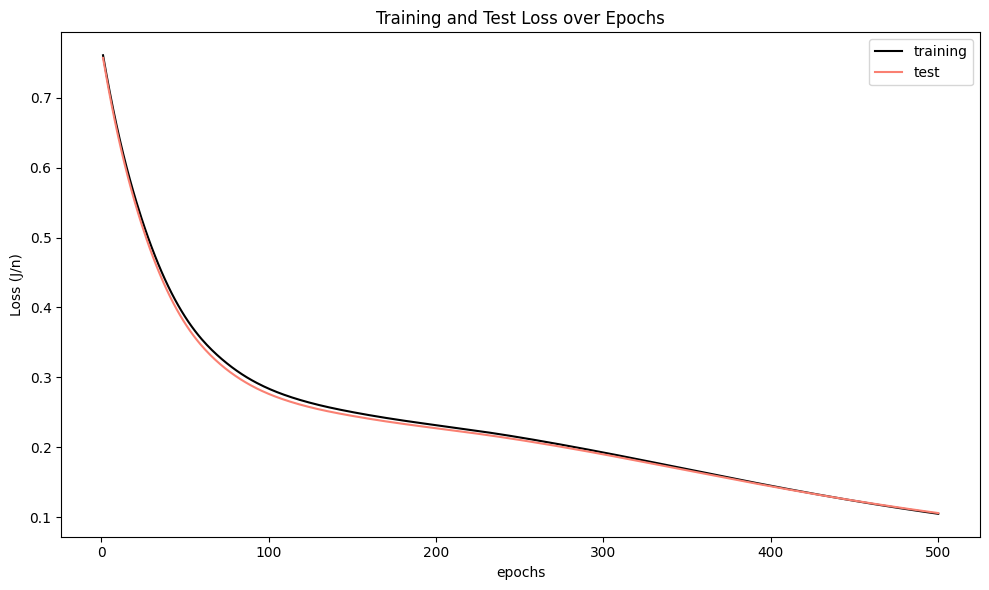

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import log_loss

# 1. 모델 초기화 (lbfgs 대신 adam 사용)
# hidden_layer_sizes는 원하시는 크기(예: 100)로 설정하시면 됩니다.
mlp = MLPClassifier(hidden_layer_sizes=(100,), activation='relu',
                    solver='adam', random_state=42)

# 에포크별 Loss를 저장할 빈 리스트 생성
train_loss_history = []
test_loss_history = []

epochs = 500 # 반복할 총 에포크 수 지정
classes = np.unique(y_train) # partial_fit에 필요한 클래스 정보

# 2. 수동 학습 루프 (Epoch 단위)
for epoch in range(epochs):
    # 1 에포크씩 훈련 진행
    mlp.partial_fit(X_train, y_train, classes=classes)

    # Train Loss 기록 (mlp.loss_ 는 현재 에포크의 훈련 손실값 반환)
    train_loss_history.append(mlp.loss_)

    # Test Loss 기록 (교차 엔트로피 손실 함수 사용)
    # MLP의 출력 확률값을 구한 뒤 log_loss로 오차를 계산합니다.
    y_test_proba = mlp.predict_proba(X_test)
    test_loss = log_loss(y_test, y_test_proba)
    test_loss_history.append(test_loss)

# 3. 그래프 시각화 (첨부 사진과 유사한 형태)
plt.figure(figsize=(10, 6))

# Train은 검은색, Test는 붉은색 계열로 표시
plt.plot(range(1, epochs + 1), train_loss_history, label='training', color='black')
plt.plot(range(1, epochs + 1), test_loss_history, label='test', color='salmon')

plt.xlabel('epochs')
plt.ylabel('Loss (J/n)')
plt.title('Training and Test Loss over Epochs')
plt.legend()
plt.tight_layout()
plt.show()

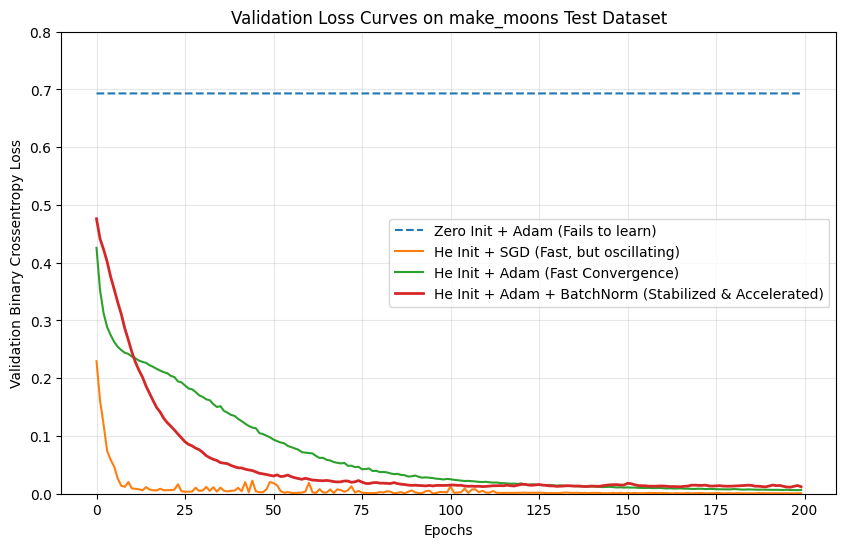

In [ ]:
# Cell 3: Keras를 활용한 Test Set 기준 훈련 궤적(Validation Loss) 실증적 비교
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Activation
from tensorflow.keras.initializers import Zeros, HeNormal

# 앞선 Cell 1에서 분할한 X_train, X_test, y_train, y_test를 그대로 사용합니다.

# 모델 생성 함수
def build_model(initializer, optimizer, use_batchnorm=False):
    model = Sequential()

    # Hidden Layer 1
    model.add(Dense(32, input_dim=2, kernel_initializer=initializer))
    if use_batchnorm: model.add(BatchNormalization())
    model.add(Activation('relu'))

    # Hidden Layer 2
    model.add(Dense(32, kernel_initializer=initializer))
    if use_batchnorm: model.add(BatchNormalization())
    model.add(Activation('relu'))

    # Output Layer
    model.add(Dense(1, activation='sigmoid', kernel_initializer=initializer))
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

# 1. Initialization 비교: Zero vs He (둘 다 Adam 사용)
model_zero = build_model(Zeros(), 'adam')
model_he = build_model(HeNormal(seed=42), 'adam')

# Train 세트로 학습하되, validation_data에 Test 세트를 전달하여 epoch마다 검증 손실을 기록
hist_zero = model_zero.fit(X_train, y_train, epochs=200, verbose=0, validation_data=(X_test, y_test))
hist_he = model_he.fit(X_train, y_train, epochs=200, verbose=0, validation_data=(X_test, y_test))

from tensorflow.keras.optimizers import SGD

# 2. Optimizer 비교: 순수 SGD (He 초기화) + 다소 높은 학습률 설정
# 학습률을 0.05 수준으로 높여서 오차 곡면에서 크게 요동치도록 유도합니다.
sgd_optimizer = SGD(learning_rate=0.05)
model_sgd = build_model(HeNormal(seed=42), sgd_optimizer)

# batch_size=1 로 설정하여 32개 묶음이 아닌 매 데이터마다(순수 SGD) 가중치를 업데이트하도록 변경
hist_sgd = model_sgd.fit(X_train, y_train, epochs=200, batch_size=1, verbose=0, validation_data=(X_test, y_test))

# 3. Batch Normalization 투입: He + Adam + BN
model_bn = build_model(HeNormal(seed=42), 'adam', use_batchnorm=True)
hist_bn = model_bn.fit(X_train, y_train, epochs=200, verbose=0, validation_data=(X_test, y_test))

# Test 데이터 기준 훈련 궤적(Validation Loss) 시각화
plt.figure(figsize=(10, 6))

# 히스토리 객체에서 'val_loss' (Test 세트 대상 Loss)를 추출하여 시각화합니다.
plt.plot(hist_zero.history['val_loss'], label='Zero Init + Adam (Fails to learn)', linestyle='--')
plt.plot(hist_sgd.history['val_loss'], label='He Init + SGD (Fast, but oscillating)')
plt.plot(hist_he.history['val_loss'], label='He Init + Adam (Fast Convergence)')
plt.plot(hist_bn.history['val_loss'], label='He Init + Adam + BatchNorm (Stabilized & Accelerated)', linewidth=2)

plt.title("Validation Loss Curves on make_moons Test Dataset")
plt.xlabel("Epochs")
plt.ylabel("Validation Binary Crossentropy Loss")
plt.ylim(0, 0.8)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


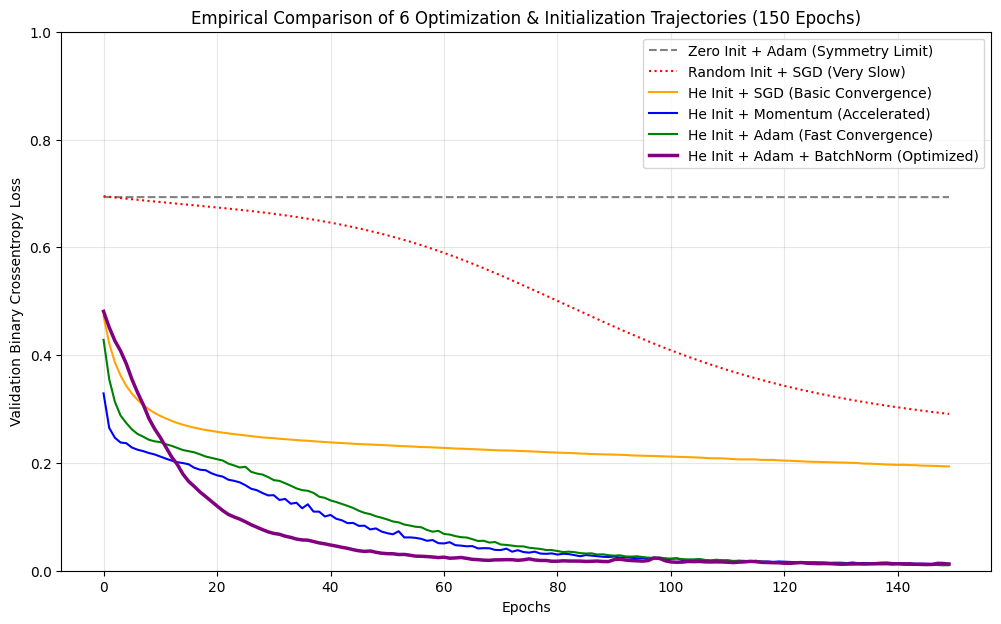

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Activation
from tensorflow.keras.initializers import Zeros, HeNormal, RandomNormal
from tensorflow.keras.optimizers import SGD, Adam
import matplotlib.pyplot as plt

# 앞선 Cell 1에서 분할한 X_train, X_test, y_train, y_test를 그대로 사용합니다.
# (만약 테스트를 위해 임의 데이터가 필요하다면 아래 주석을 해제하고 사용하세요)
# from sklearn.datasets import make_moons
# from sklearn.model_selection import train_test_split
# X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# [설정] Epoch 수 조정
EPOCHS = 150

# 모델 생성 함수
def build_model(initializer, optimizer, use_batchnorm=False):
    model = Sequential()

    # Hidden Layer 1
    model.add(Dense(32, input_dim=2, kernel_initializer=initializer))
    if use_batchnorm:
        model.add(BatchNormalization())
    model.add(Activation('relu'))

    # Hidden Layer 2
    model.add(Dense(32, kernel_initializer=initializer))
    if use_batchnorm:
        model.add(BatchNormalization())
    model.add(Activation('relu'))

    # Output Layer
    model.add(Dense(1, activation='sigmoid', kernel_initializer=initializer))
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

# --- 6가지 실험군 정의 및 훈련 ---

# 1. Zero init + Adam (학습 불가 상태 확인)
model_zero_adam = build_model(Zeros(), 'adam')
hist_zero_adam = model_zero_adam.fit(X_train, y_train, epochs=EPOCHS, verbose=0, validation_data=(X_test, y_test))

# 2. Random init + SGD (가장 원시적인 조합, 성능 한계 확인)
# 단순 무작위 정규분포(stddev=0.1) 초기화 사용
rand_init = RandomNormal(mean=0.0, stddev=0.1, seed=42)
model_rand_sgd = build_model(rand_init, SGD(learning_rate=0.01))
hist_rand_sgd = model_rand_sgd.fit(X_train, y_train, epochs=EPOCHS, verbose=0, validation_data=(X_test, y_test))

# 3. He init + SGD (기초적인 개선)
model_he_sgd = build_model(HeNormal(seed=42), SGD(learning_rate=0.01))
hist_he_sgd = model_he_sgd.fit(X_train, y_train, epochs=EPOCHS, verbose=0, validation_data=(X_test, y_test))

# 4. He init + Momentum (관성 적용을 통한 SGD 가속 및 진동 완화)
momentum_opt = SGD(learning_rate=0.01, momentum=0.9)
model_he_momentum = build_model(HeNormal(seed=42), momentum_opt)
hist_he_momentum = model_he_momentum.fit(X_train, y_train, epochs=EPOCHS, verbose=0, validation_data=(X_test, y_test))

# 5. He init + ADAM (방향과 보폭을 모두 잡은 표준 옵티마이저)
model_he_adam = build_model(HeNormal(seed=42), 'adam')
hist_he_adam = model_he_adam.fit(X_train, y_train, epochs=EPOCHS, verbose=0, validation_data=(X_test, y_test))

# 6. He init + ADAM + batch normalization (안정성과 속도 극대화)
model_he_bn_adam = build_model(HeNormal(seed=42), 'adam', use_batchnorm=True)
hist_he_bn_adam = model_he_bn_adam.fit(X_train, y_train, epochs=EPOCHS, verbose=0, validation_data=(X_test, y_test))


# --- 6가지 실험군의 Validation Loss 시각화 ---
plt.figure(figsize=(12, 7))

# 각 훈련 궤적 플로팅
plt.plot(hist_zero_adam.history['val_loss'], label='Zero Init + Adam (Symmetry Limit)', color='gray', linestyle='--')
plt.plot(hist_rand_sgd.history['val_loss'], label='Random Init + SGD (Very Slow)', color='red', linestyle=':')
plt.plot(hist_he_sgd.history['val_loss'], label='He Init + SGD (Basic Convergence)', color='orange')
plt.plot(hist_he_momentum.history['val_loss'], label='He Init + Momentum (Accelerated)', color='blue')
plt.plot(hist_he_adam.history['val_loss'], label='He Init + Adam (Fast Convergence)', color='green')
plt.plot(hist_he_bn_adam.history['val_loss'], label='He Init + Adam + BatchNorm (Optimized)', color='purple', linewidth=2.5)

plt.title("Empirical Comparison of 6 Optimization & Initialization Trajectories (150 Epochs)")
plt.xlabel("Epochs")
plt.ylabel("Validation Binary Crossentropy Loss")
plt.ylim(0, 1.0)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()